In [162]:
#импортируем
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import PolynomialFeatures
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#Данные нормализованы в датасете, будем предсказывать Age
df = pd.read_csv('processed_titanic.csv')
X = df.drop('Age', axis=1)
Y = df['Age']
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)


n = 2
poly_features = PolynomialFeatures(n)
X_train_poly = poly_features.fit_transform(X_train)
X_test_poly = poly_features.transform(X_test)
print(f"Исходное количество признаков: {X_train.shape[1]}")
print(f"После PolynomialFeatures (n={n}): {X_train_poly.shape[1]}")



linear_model = LinearRegression()
# Обучаем 
linear_model.fit(X_train_poly, Y_train)
y_pred_linear = linear_model.predict(X_test_poly)


elastic = ElasticNet(alpha=0.01, l1_ratio=0.2, max_iter=10000)
elastic.fit(X_train_poly, Y_train)
y_pred_elastic = elastic.predict(X_test_poly)




MSE = mean_squared_error(Y_test, y_pred_linear)
RMSE = MSE ** 0.5
MAE = mean_absolute_error(Y_test, y_pred_linear)
print(f"MSE: {MSE:.2f}")
print(f"RMSE: {RMSE:.2f}")
print(f"MAE: {MAE:.2f}")

print("Linear R²:", r2_score(Y_test, y_pred_linear))
print("Elastic R²:", r2_score(Y_test, y_pred_elastic))

Исходное количество признаков: 9
После PolynomialFeatures (n=2): 55
MSE: 0.02
RMSE: 0.15
MAE: 0.11
Linear R²: 0.21127685898238058
Elastic R²: 0.25747052540249804


In [168]:
ridge = Ridge(alpha=150, random_state=42)
ridge.fit(X_train_poly, Y_train)
y_pred_ridge = ridge.predict(X_test_poly)

print("Ridge R2:", r2_score(Y_test, y_pred_ridge))

Ridge R2: 0.25663284200143444


Оценка модели классификации

Accuracy (Точность): 0.7937

(Матрица ошибок):
[[113  21]
 [ 25  64]]

(Отчет о классификации):
              precision    recall  f1-score   support

           0       0.82      0.84      0.83       134
           1       0.75      0.72      0.74        89

    accuracy                           0.79       223
   macro avg       0.79      0.78      0.78       223
weighted avg       0.79      0.79      0.79       223


Расшифровка Матрицы
                 Предсказано 'Не выжил' | Предсказано 'Выжил'
Реально 'Не выжил' | 113                    | 21
Реально 'Выжил'    | 25                     | 64


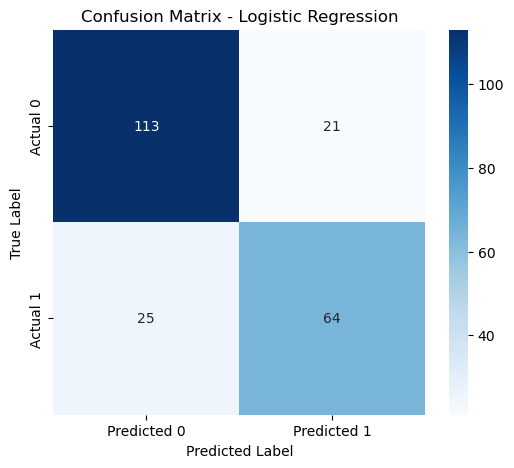

In [169]:
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

y_log = df['Survived']
X_log = df.drop('Survived', axis=1)
X_log_train, X_log_test, y_log_train, y_log_test = train_test_split(X_log, y_log, test_size=0.25, random_state=42)


model_log = LogisticRegression(max_iter=1000)
model_log.fit(X_log_train, y_log_train)
y_log_pred = model_log.predict(X_log_test)

accuracy = accuracy_score(y_log_test, y_log_pred)
conf_matrix = confusion_matrix(y_log_test, y_log_pred)
class_report = classification_report(y_log_test, y_log_pred)

print("Оценка модели классификации")
print(f"\nAccuracy (Точность): {accuracy:.4f}")

print("\n(Матрица ошибок):")
print(conf_matrix)

print("\n(Отчет о классификации):")
print(class_report)

print("\nРасшифровка Матрицы")
print("                 Предсказано 'Не выжил' | Предсказано 'Выжил'")
print(f"Реально 'Не выжил' | {conf_matrix[0][0]:<22} | {conf_matrix[0][1]}")
print(f"Реально 'Выжил'    | {conf_matrix[1][0]:<22} | {conf_matrix[1][1]}")

plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted 0', 'Predicted 1'], 
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()